# Machine Learning
Author: Scottie Housholder  
Course: MAT 311  
Updated: November 17, 2025#TODO:

In [857]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [858]:
def find_k(size):
    """
    Return the number of neighbors a KNN algorithm should have
    Returns the square root of the given number and makes sure it's odd
    """

    k = round(size**0.5)
    if k % 2 == 0:
        return k-1
    return k

In [859]:
test_data = pd.read_csv("../data/processed/test_cleaned_temp.csv", index_col=0)
train_data = pd.read_csv("../data/processed/train_cleaned_temp.csv", index_col=0)

# X = train_data.drop("Churn", axis=1).values
X = train_data[['Support Calls', "Payment Delay", "Total Spend", "Age"]]
y = train_data["Churn"]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=754)


# knn = KNeighborsClassifier(find_k(len(test_data)))
forest = RandomForestClassifier()
knn_fit1 = forest.fit(X_train1, y_train1)
prediction1 = knn_fit1.predict_proba(X_test1)[:, 1]
roc_auc_score(y_test1, prediction1)

0.9108962732328186

In [860]:
print(train_data.corrwith(train_data["Churn"]).sort_values())

Total Spend                  -0.372350
Contract Length_Quarterly    -0.141252
Contract Length_Annual       -0.138528
Usage Frequency              -0.049018
Tenure                       -0.016920
Subscription Type_Premium    -0.010027
Subscription Type_Standard   -0.006670
CustomerID                    0.001484
Subscription Type_Basic       0.016940
Last Interaction              0.100025
Gender_Female                 0.158337
Age                           0.189481
Payment Delay                 0.329147
Contract Length_Monthly       0.401125
Support Calls                 0.424620
Churn                         1.000000
Customer Status_inactive      1.000000
dtype: float64


In [861]:
train_data.columns

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn',
       'Gender_Female', 'Subscription Type_Basic', 'Subscription Type_Premium',
       'Subscription Type_Standard', 'Contract Length_Annual',
       'Contract Length_Monthly', 'Contract Length_Quarterly',
       'Customer Status_inactive'],
      dtype='object')

In [862]:
X_train = train_data[['Support Calls', "Payment Delay", "Total Spend", "Age"]]
X_test = test_data[['Support Calls', "Payment Delay", "Total Spend", "Age"]]
y_train = train_data["Churn"]
train_data.isna().sum()

CustomerID                    0
Age                           0
Tenure                        0
Usage Frequency               0
Support Calls                 0
Payment Delay                 0
Total Spend                   0
Last Interaction              0
Churn                         0
Gender_Female                 0
Subscription Type_Basic       0
Subscription Type_Premium     0
Subscription Type_Standard    0
Contract Length_Annual        0
Contract Length_Monthly       0
Contract Length_Quarterly     0
Customer Status_inactive      0
dtype: int64

In [863]:
# knn_fit = knn.fit(X_train, y_train)
forest_fit = forest.fit(X_train, y_train)

cols = X_train.columns

# knn_fit

In [864]:
test_data.columns

Index(['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Female',
       'Subscription Type_Basic', 'Subscription Type_Premium',
       'Subscription Type_Standard', 'Contract Length_Annual',
       'Contract Length_Monthly', 'Contract Length_Quarterly'],
      dtype='object')

In [865]:
# prob_predict = pd.DataFrame(knn_fit.predict_proba(X_test))
prob_predict = pd.DataFrame(forest_fit.predict_proba(X_test))
prob_predict["CustomerID"] = test_data["CustomerID"]
prob_predict = prob_predict.set_index("CustomerID")
prob_predict

,0,1
CustomerID,,
262106,0.41,0.59
37061,0.20,0.80
361832,0.50,0.50
425516,0.11,0.89
60597,0.38,0.62
...,...,...
396573,0.26,0.74
452602,0.42,0.58
424958,0.03,0.97


In [866]:
prob_predict = prob_predict.rename(columns={1:"Churn"})
prob_predict = prob_predict.drop(0, axis=1)
print(prob_predict)

            Churn
CustomerID       
262106       0.59
37061        0.80
361832       0.50
425516       0.89
60597        0.62
...           ...
396573       0.74
452602       0.58
424958       0.97
242104       0.78
132430       0.66

[133776 rows x 1 columns]


In [867]:
print(prob_predict["Churn"].unique())
print(prob_predict["Churn"].nunique())

[0.59       0.8        0.5        ... 0.76266667 0.95466667 0.27333333]
1822


In [868]:
prob_predict.head()

,Churn
CustomerID,
262106,0.59
37061,0.80
361832,0.50
425516,0.89
60597,0.62


In [869]:
prob_predict.to_csv("../submission.csv")

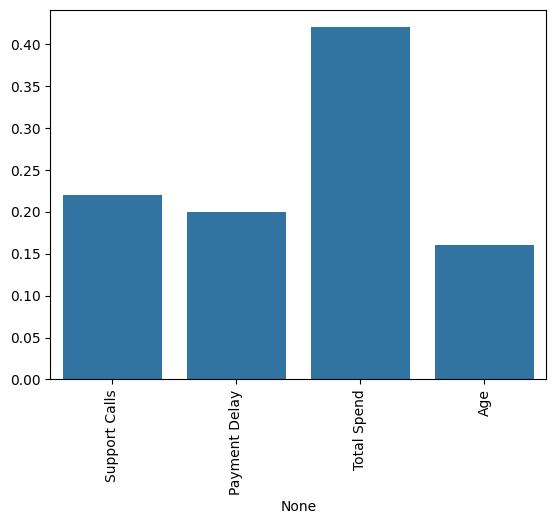

In [870]:
sns.barplot(x=cols, y=forest_fit.feature_importances_)
plt.xticks(rotation=90)
plt.show()